# Laboratorio 6 — Análisis de redes sociales

## Avance: ejercicios 1–4

**Curso:** CC3084 · Data Science · Semestre II, 2026  
**Integrantes:** Daniel Chet (231177), Dulce Ambrosio (231143) y Javier Linares (231135)

Este cuaderno documenta la carga e integración, el diagnóstico de calidad, la limpieza, el análisis exploratorio y la construcción de la red bipartita autor–video. Cada tabla, cifra y visualización puede reconstruirse desde los CSV originales.

**Decisión transversal:** no se traduce ningún comentario, título ni descripción. Se conserva el idioma original para evitar pérdida de contexto.

## 0. Configuración reproducible

El cuaderno puede ejecutarse desde la carpeta del laboratorio o desde `notebooks/`. Las funciones reutilizables viven en `src/`; los datos crudos solo se leen y las salidas se escriben en `data/processed/`.

In [1]:
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import networkx as nx
import numpy as np
import pandas as pd
import scipy
from scipy.stats import spearmanr
import seaborn as sns
from IPython.display import Markdown, display

%matplotlib inline

cwd = Path.cwd().resolve()
if (cwd / "data" / "raw").exists():
    ROOT = cwd
elif (cwd.parent / "data" / "raw").exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError("Ejecute el notebook desde la carpeta del laboratorio o notebooks/.")

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from config import PROCESSED_DIR
from data_processing import (
    clean_text_record, cleaning_effect, column_quality,
    cross_dataset_consistency, dataset_quality_summary,
    frequency_table, integrate_data, list_frequency_table,
    load_raw_data, mapping_ambiguities, outlier_summary,
    prepare_comments, prepare_videos, save_processed,
)
from network_analysis import (
    build_bipartite_graph, build_network_tables, save_network_tables,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")
COLORS = {"author": "#2A9D8F", "video": "#E76F51", "accent": "#264653"}

versions = pd.Series({
    "Python": platform.python_version(), "pandas": pd.__version__,
    "NumPy": np.__version__, "SciPy": scipy.__version__, "NetworkX": nx.__version__,
}, name="versión")
display(versions.to_frame())
print(f"Raíz del laboratorio: {ROOT}")

,versión
Python,3.13.14
pandas,3.0.5
NumPy,2.5.2
SciPy,1.18.1
NetworkX,3.6.1


Raíz del laboratorio: C:\UVG\Semestre8\CC3084 - Data Science\Tareas\Lab6-AnaliticadeRedesSociales\CC3084-Data-Science\06_analisis_redes_sociales


# 1. Carga, comprensión e integración de los datos

## 1.1 Carga y contratos de entrada

La carga valida que estén todas las columnas descritas por el enunciado y que `video_id` y `comment_id` sean llaves primarias. Si un contrato falla, el flujo se detiene antes de producir resultados derivados.

In [2]:
videos_raw, comments_raw = load_raw_data()

dimensions = pd.DataFrame({
    "dataset": ["youtube_videos.csv", "youtube_comments.csv"],
    "filas": [len(videos_raw), len(comments_raw)],
    "columnas": [videos_raw.shape[1], comments_raw.shape[1]],
})
display(dimensions)
display(videos_raw[["video_id", "title", "channel_name", "channel_id", "view_count"]].head(3))
display(comments_raw[["comment_id", "video_id", "author_name", "author_channel_id", "text"]].head(3))

,dataset,filas,columnas
0,youtube_videos.csv,293,20
1,youtube_comments.csv,406,17


,video_id,title,channel_name,channel_id,view_count
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias para el fin de semana en Guatemala,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,2357
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO EL FIN DE UNA ETAPA DE DETERIORO INSTITUCIONAL,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,4
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado por Guatemala... 🔔,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,29736


,comment_id,video_id,author_name,author_channel_id,text
0,Ugw-J65a1iYL9hqhELh4AaABAg,j43HgwYFKfk,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel
1,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,06mFNPU0aB8,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay policías que le gusta del otro vando , por ir..."
2,Ugw0xaOb2CYXXoudtwJ4AaABAg,j43HgwYFKfk,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila"


## 1.2 Unidad de observación, llaves y variables relevantes

| Archivo | Unidad de observación | Llave primaria | Llaves/variables relacionales |
|---|---|---|---|
| `youtube_videos.csv` | un video | `video_id` | `channel_id`, `category`, `source_query` |
| `youtube_comments.csv` | un comentario principal | `comment_id` | `video_id` (foránea), `channel_id`, `author_channel_id` |

Los nombres y handles son atributos para mostrar; los IDs permanecen como identificadores. La definición de las 37 variables originales y las derivadas está en `codebook.md`.

In [3]:
key_audit = pd.DataFrame([
    {"dataset": "videos", "llave": "video_id",
     "faltantes": int(videos_raw["video_id"].isna().sum()),
     "duplicadas": int(videos_raw["video_id"].duplicated().sum()),
     "es_llave_primaria": videos_raw["video_id"].notna().all() and videos_raw["video_id"].is_unique},
    {"dataset": "comentarios", "llave": "comment_id",
     "faltantes": int(comments_raw["comment_id"].isna().sum()),
     "duplicadas": int(comments_raw["comment_id"].duplicated().sum()),
     "es_llave_primaria": comments_raw["comment_id"].notna().all() and comments_raw["comment_id"].is_unique},
])
display(key_audit)

,dataset,llave,faltantes,duplicadas,es_llave_primaria
0,videos,video_id,0,0,True
1,comentarios,comment_id,0,0,True


## 1.3 Relación entre las entidades

```text
canal (channel_id)
  └── publica → video (video_id)
                   ├── pertenece a → categoría
                   ├── fue recuperado por → consulta de búsqueda
                   └── recibe → comentario (comment_id)
                                      └── escrito por → autor (author_channel_id)
```

El `channel_id` del comentario identifica al canal propietario del video; **no** al autor. El autor se identifica con `author_channel_id`. Un autor puede comentar varios videos y un video puede recibir comentarios de varios autores, lo que motiva la red bipartita del ejercicio 4.

## 1.4 Integración por `video_id`

Se usa un `left join` desde comentarios hacia videos y se exige una relación `many_to_one`: cada comentario puede encontrar como máximo un video porque `video_id` es único en la tabla de videos.

In [4]:
join_check = comments_raw[["comment_id", "video_id"]].merge(
    videos_raw[["video_id", "title"]], on="video_id", how="left",
    validate="many_to_one", indicator=True,
)
integration_audit = join_check["_merge"].value_counts(dropna=False).rename_axis("resultado").reset_index(name="comentarios")
integration_audit["porcentaje"] = 100 * integration_audit["comentarios"] / len(join_check)
display(integration_audit)

linked = int(join_check["_merge"].eq("both").sum())
display(Markdown(
    f"**Resultado:** {linked} de {len(join_check)} comentarios "
    f"({linked / len(join_check):.1%}) pudieron asociarse con un video."
))

,resultado,comentarios,porcentaje
0,both,406,100.0
1,left_only,0,0.0
2,right_only,0,0.0


**Resultado:** 406 de 406 comentarios (100.0%) pudieron asociarse con un video.

# 2. Calidad, limpieza y preprocesamiento

## 2.1 Diagnóstico inicial

El diagnóstico cubre dimensiones, tipos, faltantes, duplicados, variables constantes y totalmente vacías. Los atípicos se detectan con la regla de 1.5 veces el rango intercuartílico; se reportan, pero no se eliminan automáticamente porque un video viral o un comentario muy respondido puede ser una observación válida.

In [5]:
general_quality = pd.concat([
    dataset_quality_summary(videos_raw, "videos", "video_id"),
    dataset_quality_summary(comments_raw, "comentarios", "comment_id"),
], ignore_index=True)
column_diagnostics = pd.concat([
    column_quality(videos_raw, "videos"),
    column_quality(comments_raw, "comentarios"),
], ignore_index=True)

display(general_quality)
display(column_diagnostics[["dataset", "variable", "dtype"]])
display(column_diagnostics.loc[
    column_diagnostics["faltantes"].gt(0)
    | column_diagnostics["constante"]
    | column_diagnostics["totalmente_vacia"]
].sort_values(["dataset", "porcentaje_faltante"], ascending=[True, False]))

,dataset,filas,columnas,filas_duplicadas,llave_duplicada,variables_constantes,variables_totalmente_vacias
0,videos,293,20,0,0,ninguna,ninguna
1,comentarios,406,17,0,0,is_pinned,viewer_rating


,dataset,variable,dtype
0,videos,video_id,str
1,videos,title,str
2,videos,channel_name,str
3,videos,channel_id,str
4,videos,source_query,str
5,videos,source_group,str
6,videos,dataset_sources,str
7,videos,channel_handle,str
8,videos,published_time,str
9,videos,view_count_text,str


,dataset,variable,dtype,faltantes,porcentaje_faltante,valores_unicos,constante,totalmente_vacia
36,comentarios,viewer_rating,float64,406,100.00,0,False,True
35,comentarios,is_pinned,bool,0,0.00,1,True,False
14,videos,description,str,26,8.87,234,False,False
10,videos,description_snippet,str,25,8.53,236,False,False
8,videos,published_time,str,13,4.44,80,False,False
9,videos,view_count_text,str,13,4.44,259,False,False


In [6]:
videos = prepare_videos(videos_raw)
comments = prepare_comments(comments_raw)
integrated = integrate_data(comments, videos)

outliers = pd.concat([
    outlier_summary(videos, ["view_count", "view_count_text_num"], "videos"),
    outlier_summary(comments, ["like_count", "reply_count"], "comentarios"),
], ignore_index=True)
display(outliers.round(2))

,dataset,variable,minimo,q1,mediana,q3,maximo,limite_inferior_iqr,limite_superior_iqr,atipicos_iqr
0,videos,view_count,2,215.0,1175.0,7465.0,8190449,-10660.00,18340.00,49
1,videos,view_count_text_num,2,215.0,1274.0,7778.5,8190449,-11130.25,19123.75,49
2,comentarios,like_count,1,1.0,2.0,4.0,405,-3.50,8.50,34
3,comentarios,reply_count,0,0.0,0.0,0.0,7,0.00,0.00,30


Los conteos presentan colas derechas largas: pocas observaciones concentran muchas visualizaciones, respuestas o me gusta. Por eso se conservan y las visualizaciones posteriores usan `log1p` cuando corresponde. La regla IQR identifica rareza estadística, no errores de captura.

### Consistencia entre IDs, nombres y handles

Un ID puede tener distintas etiquetas visibles porque un usuario puede cambiar su nombre o porque la recolección integró fuentes distintas. Se auditan esas ambigüedades sin reemplazar los IDs. También se comparan título y canal redundantes en comentarios con la tabla de videos.

In [7]:
mapping_checks = pd.concat([
    mapping_ambiguities(videos, "videos", "channel_id", "channel_name"),
    mapping_ambiguities(videos, "videos", "channel_id", "channel_handle"),
    mapping_ambiguities(videos, "videos", "channel_id", "owner_handle"),
    mapping_ambiguities(comments, "comentarios", "author_channel_id", "author_name"),
    mapping_ambiguities(comments, "comentarios", "author_channel_id", "author_handle"),
], ignore_index=True)
display(mapping_checks)
display(cross_dataset_consistency(comments, videos))

,dataset,id,etiqueta,ids_con_multiples_etiquetas,maximo_etiquetas_por_id
0,videos,channel_id,channel_name,0,1
1,videos,channel_id,channel_handle,0,1
2,videos,channel_id,owner_handle,0,1
3,comentarios,author_channel_id,author_name,0,1
4,comentarios,author_channel_id,author_handle,0,1


,variable_comentarios,variable_referencia_videos,comparables,diferencias
0,video_title,title_ref,406,0
1,channel_id,channel_id_ref,406,0
2,channel_name,channel_name_ref,406,0


## 2.2 Variables problemáticas o de uso delicado

| Variable | Tratamiento y precaución |
|---|---|
| `viewer_rating` | totalmente vacía; se documenta y no se analiza. |
| `is_pinned` | constante en la muestra; no explica variación. |
| `published_time`, `published_text` | tiempos relativos; no se convierten en fechas exactas. |
| `reply_count` | se usa como conteo, nunca como arista entre autores. |
| `like_count_text` vacío | se conserva como desconocido (`NA`), no como cero. |
| `source_query`, `source_group` | describen el muestreo; no equivalen necesariamente al tema real. |
| nombres y handles | pueden cambiar o repetirse; se muestran como etiquetas pero no identifican nodos. |
| visualizaciones, me gusta y respuestas | fotografías del momento de recolección, no conteos finales. |
| `upload_date` | se audita frente a `publish_date`; no se considera una medición independiente si coinciden. |

## 2.3 Normalización de identificadores y nombres

Solo se recortan espacios externos en IDs. En nombres y handles también se colapsan espacios repetidos. No se cambian mayúsculas internas, acentos ni contenido semántico y nunca se sustituye un ID por una etiqueta visible.

In [8]:
normalization_rows = []
for dataset, raw, clean, columns in [
    ("videos", videos_raw, videos, ["video_id", "channel_id", "title", "channel_name", "channel_handle"]),
    ("comentarios", comments_raw, comments, ["video_id", "comment_id", "channel_id", "author_channel_id", "author_name", "author_handle"]),
]:
    for column in columns:
        before = raw[column].astype("string").fillna("<NA>")
        after = clean[column].astype("string").fillna("<NA>")
        normalization_rows.append({
            "dataset": dataset, "variable": column,
            "valores_modificados": int(before.ne(after).sum()),
        })
display(pd.DataFrame(normalization_rows))

,dataset,variable,valores_modificados
0,videos,video_id,0
1,videos,channel_id,0
2,videos,title,20
3,videos,channel_name,1
4,videos,channel_handle,0
5,comentarios,video_id,0
6,comentarios,comment_id,0
7,comentarios,channel_id,0
8,comentarios,author_channel_id,0
9,comentarios,author_name,0


## 2.4 Conversión de conteos almacenados como texto

El conversor elimina separadores de miles y reconoce abreviaturas (`k`, `mil`, `m`, `millón/es`). Un valor vacío o no interpretable queda como `NA`. `view_count`, que ya es numérico, funciona como referencia para auditar `view_count_text_num`.

In [9]:
view_nonempty = videos_raw["view_count_text"].astype("string").fillna("").str.strip().ne("")
like_nonempty = comments_raw["like_count_text"].astype("string").fillna("").str.strip().ne("")
view_comparable = videos["view_count_text_num"].notna() & videos["view_count"].notna()

conversion_audit = pd.DataFrame([
    {"variable_origen": "view_count_text", "variable_numerica": "view_count_text_num",
     "valores_no_vacios": int(view_nonempty.sum()),
     "conversiones_validas": int(videos["view_count_text_num"].notna().sum()),
     "no_validos": int((view_nonempty & videos["view_count_text_num"].isna()).sum())},
    {"variable_origen": "like_count_text", "variable_numerica": "like_count",
     "valores_no_vacios": int(like_nonempty.sum()),
     "conversiones_validas": int(comments["like_count"].notna().sum()),
     "no_validos": int((like_nonempty & comments["like_count"].isna()).sum())},
])
display(conversion_audit)
display(Markdown(
    f"Entre {int(view_comparable.sum())} conteos de vistas comparables, "
    f"{int((videos.loc[view_comparable, 'view_count_text_num'] == videos.loc[view_comparable, 'view_count']).sum())} "
    "coinciden exactamente con `view_count`."
))
display(comments[["like_count_text", "like_count"]].drop_duplicates().head(15))

date_audit = pd.DataFrame([{
    "fechas_publicación_inválidas": int(videos["publish_datetime"].isna().sum()),
    "fechas_carga_inválidas": int(videos["upload_datetime"].isna().sum()),
    "publicación_igual_a_carga": int(videos["publish_datetime"].eq(videos["upload_datetime"]).sum()),
    "videos": len(videos),
}])
display(date_audit)

,variable_origen,variable_numerica,valores_no_vacios,conversiones_validas,no_validos
0,view_count_text,view_count_text_num,280,280,0
1,like_count_text,like_count,217,217,0


Entre 280 conteos de vistas comparables, 227 coinciden exactamente con `view_count`.

,like_count_text,like_count
0,,<NA>
2,4,4
4,2,2
7,3,3
11,1,1
13,5,5
14,6,6
21,31,31
22,10,10
23,8,8


,fechas_publicación_inválidas,fechas_carga_inválidas,publicación_igual_a_carga,videos
0,0,0,293,293


Las diferencias entre el conteo textual y view_count no se corrigen por la fuerza: pueden reflejar capturas en momentos o etapas distintas. Para los cálculos se usa la columna numérica view_count recomendada por el enunciado. Las fechas de publicación y carga se conservan separadas, aunque su coincidencia completa indica que aquí no aportan dos mediciones temporales independientes.

## 2.5–2.6 Texto original y texto limpio

`texto_original` es una copia exacta de `text`. `texto_limpio` se usa para frecuencias y conserva una versión auditable de hashtags, menciones y emojis en columnas separadas.

| Decisión | Aplicación |
|---|---|
| traducción | **no se aplica**; se conserva cada idioma original. |
| minúsculas | sí, mediante `casefold`, solo en `texto_limpio`. |
| URL | se eliminan del texto analítico. |
| hashtags | se extraen y se conserva la palabra sin `#`. |
| menciones | se extraen y se retiran del texto analítico para no confundir usuarios con temas. |
| puntuación y números | se retiran para el análisis léxico de este avance. |
| stopwords | se retiran stopwords españolas e inglesas; se preservan negaciones como `no`, `nunca`, `not` y `never`. |
| emojis | se extraen a una lista; permanecen intactos en `texto_original`. |
| lematización | se evalúa, pero **no se aplica al corpus** porque contiene varios idiomas. |

In [10]:
feature_score = (
    comments["hashtags"].ne("[]").astype(int)
    + comments["menciones"].ne("[]").astype(int)
    + comments["emojis"].ne("[]").astype(int)
)
sample_text = comments.assign(_score=feature_score).sort_values(
    ["_score", "comment_id"], ascending=[False, True]
)[["texto_original", "texto_limpio", "hashtags", "menciones", "emojis"]].head(8)
display(sample_text)

,texto_original,texto_limpio,hashtags,menciones,emojis
121,​ @rosadiaz6945 \nSure 👌 \nWhatever you say!,sure,[],"[""rosadiaz6945""]","[""👌""]"
133,​ @luisricardo9671 comentario bien acertado saludos amigo🧐🧐🧐,comentario acertado saludos amigo,[],"[""luisricardo9671""]","[""🧐"", ""🧐"", ""🧐""]"
139,​ @Murmullodelbarrio 👍🇬🇹,,[],"[""Murmullodelbarrio""]","[""👍"", ""🇬🇹""]"
8,Viva Guatemala 🇬🇹🇬🇹🇬🇹🥳🥳🥳,viva guatemala,[],[],"[""🇬🇹"", ""🇬🇹"", ""🇬🇹"", ""🥳"", ""🥳"", ""🥳""]"
10,Otro pequeño truco es que tenés un plan mensual de Gb y redes ilimitadas y luego te mandan mensaje que consumiste el...,pequeño truco tenés plan mensual gb redes ilimitadas mandan mensaje consumiste plan viene caos verificas consumo dat...,[],[],"[""🤮"", ""🤮"", ""😠"", ""😠"", ""💵"", ""💵""]"
27,Qué lujooo de contenidooooo 🔥,lujooo contenidooooo,[],[],"[""🔥""]"
31,"Entoces las mismas 💩😡 Junta Directiva haciéndose de las suyas con el dinero del Estado. Ya basta de tanto robo, barr...",entoces junta directiva haciéndose dinero basta robo barriles sin fondos,[],[],"[""💩"", ""😡"", ""💩"", ""😡""]"
38,😮,,[],[],"[""😮""]"


### Evaluación de la lematización sin modificar el corpus

El modelo español puede agrupar formas flexionadas y producir términos más interpretables, pero al aplicarlo a texto en inglés u otro idioma puede generar análisis lingüísticos incorrectos. La siguiente comparación es diagnóstica; `texto_limpio` no usa estos lemas.

In [11]:
import spacy

nlp_es = spacy.load("es_core_news_sm", disable=["parser", "ner"])
spanish_candidates = comments.loc[
    comments["texto_original"].str.contains(r"\b(?:guatemala|gobierno|ciudad)\b", case=False, na=False),
    "texto_original",
]
other_candidates = comments.loc[
    comments["texto_original"].str.contains(r"\b(?:the|this|law|people)\b", case=False, na=False),
    "texto_original",
]
lemma_examples = []
for language_hint, series in [("probablemente español", spanish_candidates), ("posiblemente otro idioma", other_candidates)]:
    if len(series):
        original = series.iloc[0][:240]
        lemmas = " ".join(token.lemma_ for token in nlp_es(original) if not token.is_space)
        lemma_examples.append({
            "observación": language_hint, "texto_original": original,
            "salida_modelo_es": lemmas,
        })
display(pd.DataFrame(lemma_examples))

,observación,texto_original,salida_modelo_es
0,probablemente español,Viva Guatemala 🇬🇹🇬🇹🇬🇹🥳🥳🥳,Viva Guatemala 🇬 🇹 🇬 🇹 🇬 🇹 🥳 🥳 🥳
1,posiblemente otro idioma,It ghe LAW \nYou don't make your own rules!,It ghe LAW You don't make your own rul !


## 2.7 Efecto cuantificado de la limpieza

No se elimina ninguna fila: incluso un texto que quedara vacío después de retirar ruido conserva su comentario e ID para auditoría y para la estructura de la red.

In [12]:
effect = cleaning_effect(comments)
display(effect)

save_processed(videos, comments, integrated)
processed_files = sorted(path.name for path in PROCESSED_DIR.glob("*.csv"))
print("Tablas limpias guardadas:", ", ".join(processed_files))

,metrica,valor
0,registros_totales,406
1,registros_eliminados,0
2,registros_modificados,403
3,textos_vacios_antes,0
4,textos_vacios_despues,8
5,duplicados_texto_antes,2
6,duplicados_texto_despues,5


Tablas limpias guardadas: network_edges.csv, network_nodes.csv, youtube_comments_clean.csv, youtube_comments_integrated.csv, youtube_videos_clean.csv


# 3. Análisis exploratorio

## 3.1 Descripción de videos, canales, comentarios y autores

Los conteos siguientes usan IDs únicos. Las tablas de participación se construyen con los comentarios efectivamente recolectados, no con el total histórico visible en YouTube.

In [13]:
overview = pd.DataFrame({
    "elemento": ["videos", "canales", "comentarios", "autores"],
    "cantidad": [videos["video_id"].nunique(), videos["channel_id"].nunique(),
                 comments["comment_id"].nunique(), comments["author_channel_id"].nunique()],
})

videos_by_channel = (
    videos.groupby(["channel_id", "channel_name"], dropna=False).size()
    .reset_index(name="videos").sort_values("videos", ascending=False)
)
comments_by_video = (
    comments.groupby("video_id")
    .agg(comentarios=("comment_id", "size"),
         autores_unicos=("author_channel_id", "nunique"),
         respuestas=("reply_count", "sum"),
         me_gusta_conocidos=("like_count", "sum"))
    .reset_index()
    .merge(videos[["video_id", "title", "channel_id", "channel_name", "view_count"]], on="video_id", how="left")
    .sort_values(["comentarios", "autores_unicos"], ascending=False)
)
comments_by_channel = (
    comments.groupby(["channel_id", "channel_name"], dropna=False)
    .agg(comentarios=("comment_id", "size"), autores_unicos=("author_channel_id", "nunique"))
    .reset_index().sort_values("comentarios", ascending=False)
)

display(overview)
display(videos_by_channel.head(10))
display(comments_by_video.head(10))
display(comments_by_channel.head(10))

,elemento,cantidad
0,videos,293
1,canales,97
2,comentarios,406
3,autores,332


,channel_id,channel_name,videos
3,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,32
54,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,27
26,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,18
28,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,17
15,UC8u2nvyHewt-mjdWSj0HJmQ,Ministerio de Gobernación,14
63,UCaivrAhro2BpsJdrPe-IyRg,Diario de Centro América,11
17,UCAutgrPkiLhZxTB-Ujje1fw,CIV -Ministerio de Comunicaciones,11
52,UCW_PHqwqCCalvQGOEsVU0jw,Concejales de Oposición - Muni Guate,10
34,UCHsYnV67K3J0yJ4QeciVCww,PNCdeGuatemala,10
7,UC6SA1dVHvAkc6yNS_t5cbGw,Conred,8


,video_id,comentarios,autores_unicos,respuestas,me_gusta_conocidos,title,channel_id,channel_name,view_count
14,n8iP75gIpmw,161,128,3,358,Qué rico come tu diputado,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,11775
12,j43HgwYFKfk,50,49,0,91,La cooptación de Walter Mazariegos en la USAC,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,10156
2,6W4u8sGEnGM,45,32,11,90,Inician los trabajos de recuperación del Puente Belice II.,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,11670
13,lj983NWyAQY,25,25,16,1697,Plan 2032 Ciudad de Guatemala,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,304089
5,PjmxCj-a9Hg,25,19,4,20,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,3628
4,OkXlHx0hx-8,25,18,13,25,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,14200
17,yLZS3JiEBg8,16,16,0,13,Arroz con pollo a la MONOPOLIO,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,1954
0,06mFNPU0aB8,14,13,1,12,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,6692
15,ndAZjHqzzT8,12,10,1,3,Internet: escoger el menos malo,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,717
10,b_Hkrkl3adA,7,7,1,1,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas principales,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,5469


,channel_id,channel_name,comentarios,autores_unicos
1,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,256,214
0,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,70,50
3,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,25,18
5,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,25,25
4,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,14,13
2,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,7,7
7,UCt5Dw7ePnn0AqPqRF8Xpjkw,TN23 Guatemala,7,7
6,UCdSVqHGHzyMTXSafUHY-e-w,Noticiero Guatevisión 13 Hrs.,2,2


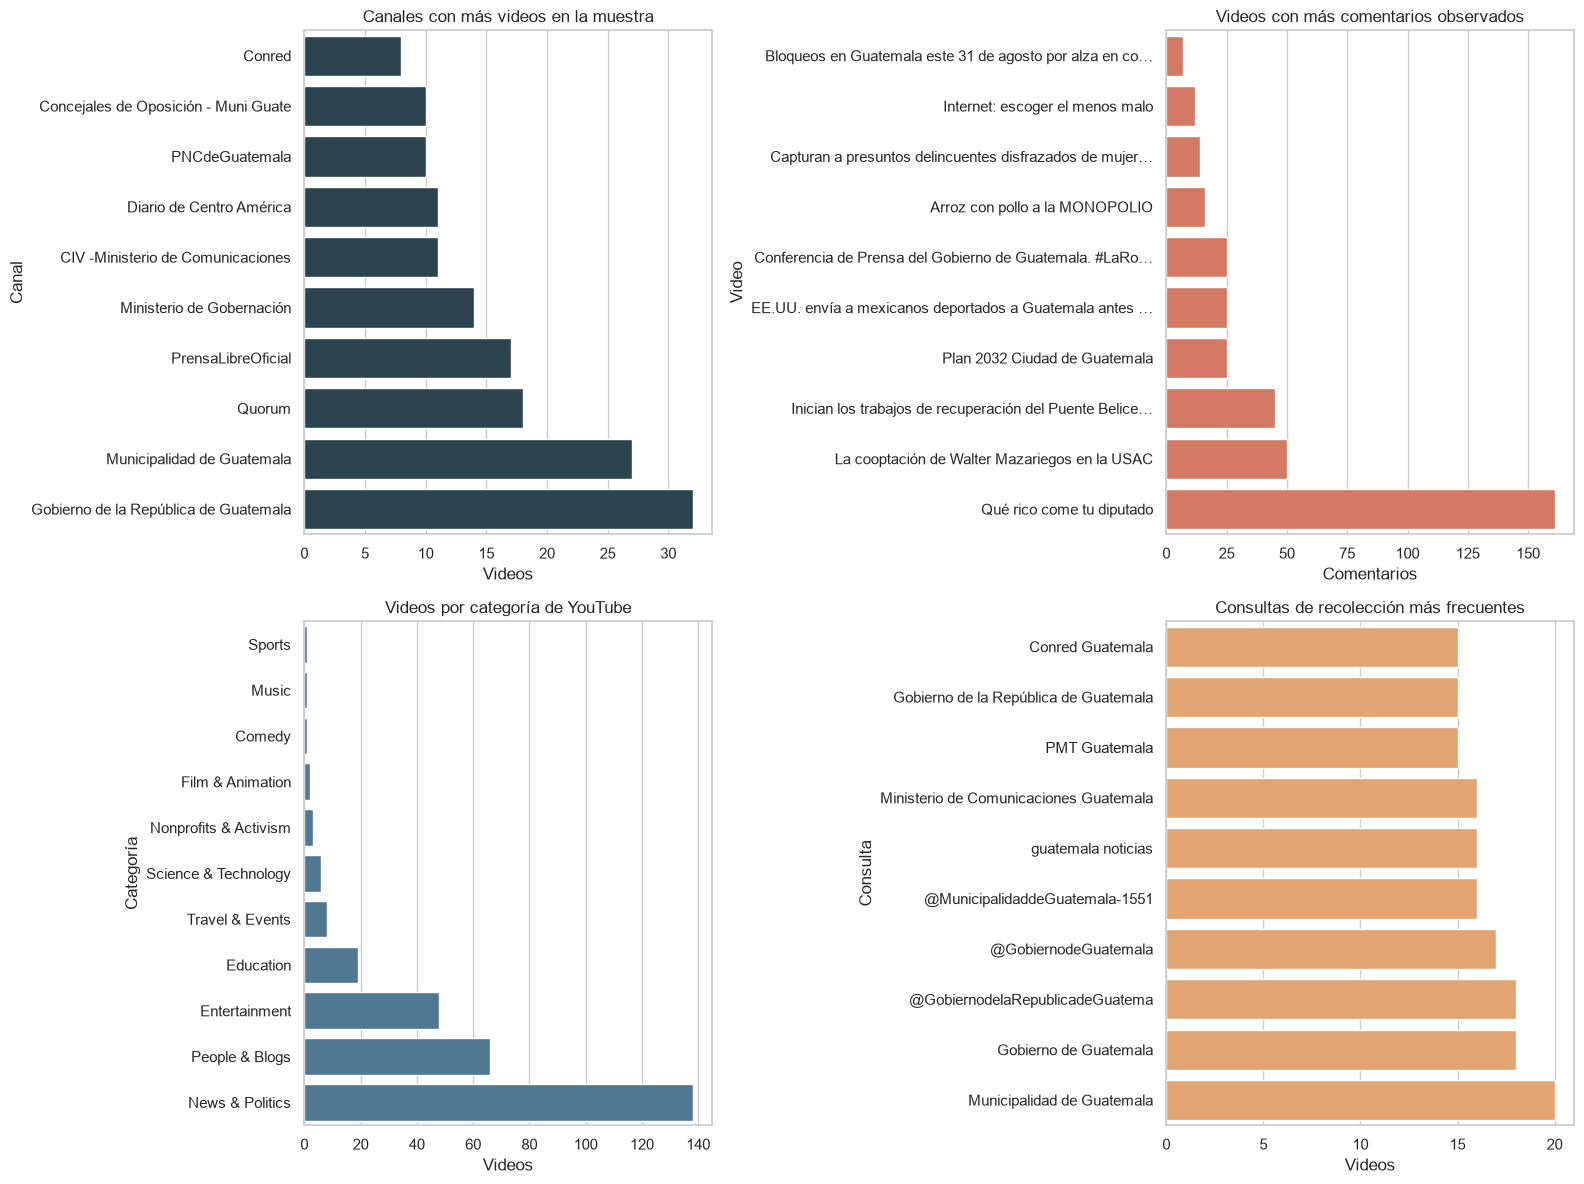

In [14]:
def shorten(value, width=55):
    value = str(value)
    return value if len(value) <= width else value[: width - 1] + "…"

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

top_channels_videos = videos_by_channel.head(10).sort_values("videos")
sns.barplot(data=top_channels_videos, x="videos", y="channel_name", color=COLORS["accent"], ax=axes[0, 0])
axes[0, 0].set_title("Canales con más videos en la muestra")
axes[0, 0].set(xlabel="Videos", ylabel="Canal")

top_videos_comments = comments_by_video.head(10).copy().sort_values("comentarios")
top_videos_comments["etiqueta"] = top_videos_comments["title"].map(shorten)
sns.barplot(data=top_videos_comments, x="comentarios", y="etiqueta", color=COLORS["video"], ax=axes[0, 1])
axes[0, 1].set_title("Videos con más comentarios observados")
axes[0, 1].set(xlabel="Comentarios", ylabel="Video")

category_counts = videos["category"].value_counts().rename_axis("category").reset_index(name="videos")
sns.barplot(data=category_counts.sort_values("videos"), x="videos", y="category", color="#457B9D", ax=axes[1, 0])
axes[1, 0].set_title("Videos por categoría de YouTube")
axes[1, 0].set(xlabel="Videos", ylabel="Categoría")

query_counts = videos["source_query"].value_counts().head(10).rename_axis("source_query").reset_index(name="videos")
sns.barplot(data=query_counts.sort_values("videos"), x="videos", y="source_query", color="#F4A261", ax=axes[1, 1])
axes[1, 1].set_title("Consultas de recolección más frecuentes")
axes[1, 1].set(xlabel="Videos", ylabel="Consulta")

plt.tight_layout()
plt.show()

Las categorías y consultas describen la composición de esta muestra. Una categoría amplia como *News & Politics* o una consulta frecuente no demuestra que ese tema domine YouTube en general: refleja, en parte, cómo se recolectaron los datos.

,count,mean,std,min,25%,50%,75%,90%,95%,max
visualizaciones,293.0,60430.09,515798.31,2.0,215.0,1175.0,7465.0,51318.8,130467.0,8190449.0
respuestas,406.0,0.13,0.58,0.0,0.0,0.0,0.0,0.0,1.0,7.0
me_gusta_conocidos,217.0,10.71,41.34,1.0,1.0,2.0,4.0,13.4,31.8,405.0


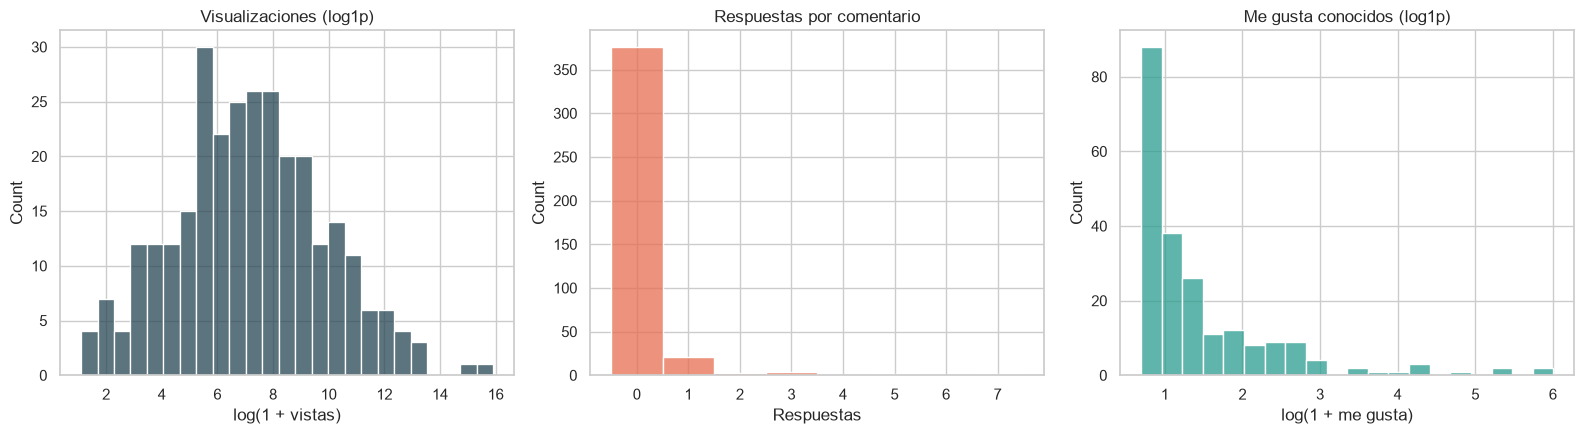

In [15]:
numeric_summary = pd.concat([
    videos["view_count"].rename("visualizaciones").describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]),
    comments["reply_count"].rename("respuestas").describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]),
    comments["like_count"].rename("me_gusta_conocidos").describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]),
], axis=1).T
display(numeric_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(np.log1p(videos["view_count"].dropna()), bins=25, color=COLORS["accent"], ax=axes[0])
axes[0].set(title="Visualizaciones (log1p)", xlabel="log(1 + vistas)")
sns.histplot(comments["reply_count"].dropna(), discrete=True, color=COLORS["video"], ax=axes[1])
axes[1].set(title="Respuestas por comentario", xlabel="Respuestas")
sns.histplot(np.log1p(comments["like_count"].dropna()), bins=20, color=COLORS["author"], ax=axes[2])
axes[2].set(title="Me gusta conocidos (log1p)", xlabel="log(1 + me gusta)")
plt.tight_layout()
plt.show()

### Hashtags, palabras y bigramas

Las palabras y bigramas se cuentan en comentarios después de la limpieza conservadora. Los hashtags se reportan por separado para comentarios y para metadatos de videos (título + descripción). Una nube de palabras no se usa porque no sustituye los conteos comparables.

In [16]:
comment_hashtags = list_frequency_table(comments["hashtags"], "hashtag", top_n=15)
video_text = videos["title"].fillna("").astype(str) + " " + videos["description"].fillna("").astype(str)
video_hashtags_json = video_text.map(lambda value: clean_text_record(value)["hashtags"])
video_hashtags = list_frequency_table(video_hashtags_json, "hashtag", top_n=15)
top_words = frequency_table(comments["texto_limpio"], ngram=1, top_n=15)
top_bigrams = frequency_table(comments["texto_limpio"], ngram=2, top_n=15)

display(Markdown("**Hashtags en comentarios**")); display(comment_hashtags)
display(Markdown("**Hashtags en títulos y descripciones de videos**")); display(video_hashtags)
display(Markdown("**Palabras en comentarios**")); display(top_words)
display(Markdown("**Bigramas en comentarios**")); display(top_bigrams)

**Hashtags en comentarios**

,hashtag,frecuencia
0,ineptobran,1


**Hashtags en títulos y descripciones de videos**

,hashtag,frecuencia
0,guatemala,48
1,larondagt,29
2,noticias,14
3,envivodca,12
4,nacionales,7
5,like,7
6,comenta,7
7,comparte,7
8,siguenos,7
9,protegeryservir,6


**Palabras en comentarios**

,palabra,frecuencia
0,no,196
1,pueblo,56
2,guatemala,52
3,dinero,34
4,presidente,32
5,país,31
6,trabajo,30
7,diputados,28
8,corruptos,24
9,diputado,22


**Bigramas en comentarios**

,2-grama,frecuencia
0,presidente bernardo,9
1,bernardo arevalo,8
2,diputados no,6
3,ciudad guatemala,6
4,cosas no,5
5,nery rodas,5
6,bla bla,5
7,pacto corruptos,5
8,viva guatemala,4
9,busquen trabajo,4


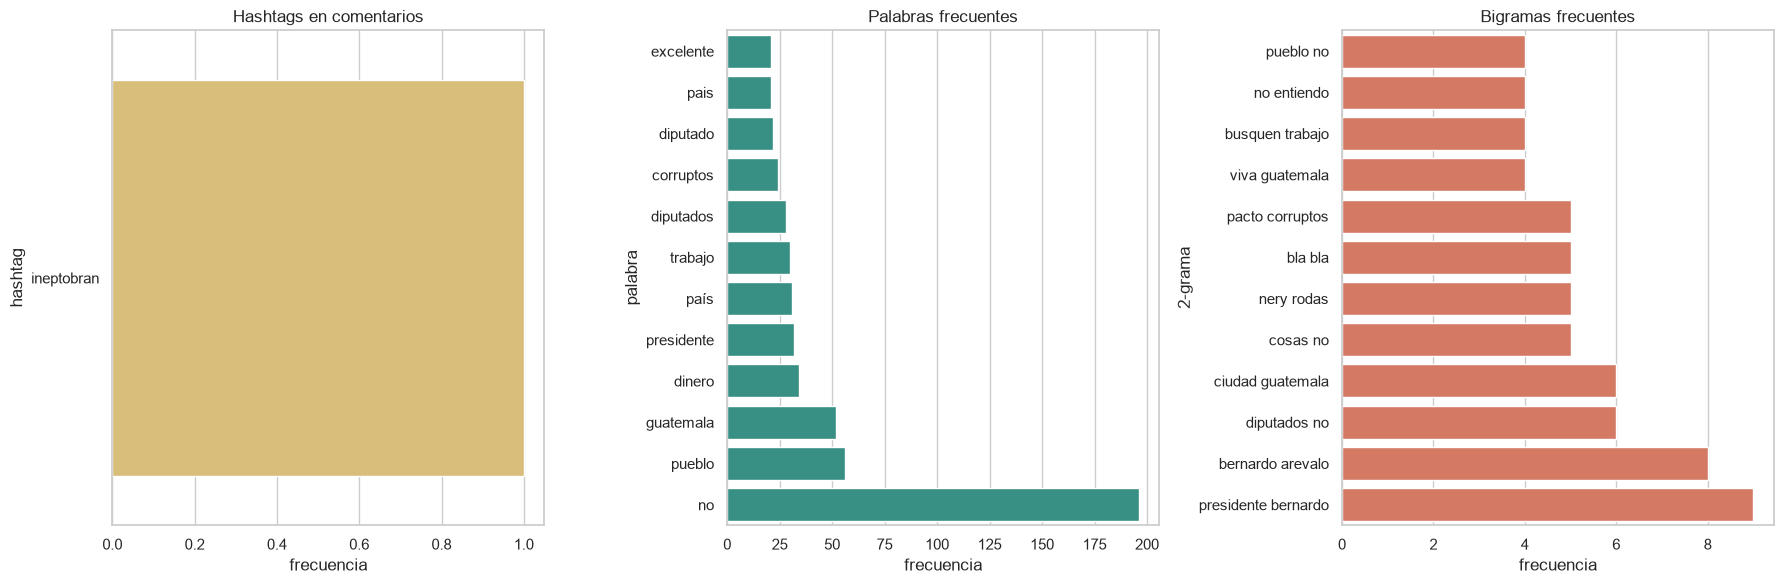

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_hashtags = comment_hashtags.head(12).sort_values("frecuencia")
if len(plot_hashtags):
    sns.barplot(data=plot_hashtags, x="frecuencia", y="hashtag", color="#E9C46A", ax=axes[0])
axes[0].set_title("Hashtags en comentarios")

plot_words = top_words.head(12).sort_values("frecuencia")
sns.barplot(data=plot_words, x="frecuencia", y="palabra", color=COLORS["author"], ax=axes[1])
axes[1].set_title("Palabras frecuentes")

plot_bigrams = top_bigrams.head(12).sort_values("frecuencia")
sns.barplot(data=plot_bigrams, x="frecuencia", y="2-grama", color=COLORS["video"], ax=axes[2])
axes[2].set_title("Bigramas frecuentes")

plt.tight_layout()
plt.show()

## 3.2 Concentración de la participación

Se calcula qué porcentaje de los comentarios corresponde a los elementos más activos. Para las curvas acumuladas se incluyen los videos y canales sin comentarios observados, porque excluirlos ocultaría parte de la concentración.

,entidad,cantidad_entidades,participación_top_1,participación_top_5,participación_top_10,participación_top_20pct_entidades
0,videos,293,39.7%,75.4%,93.6%,100.0%
1,canales,97,63.1%,96.1%,100.0%,100.0%


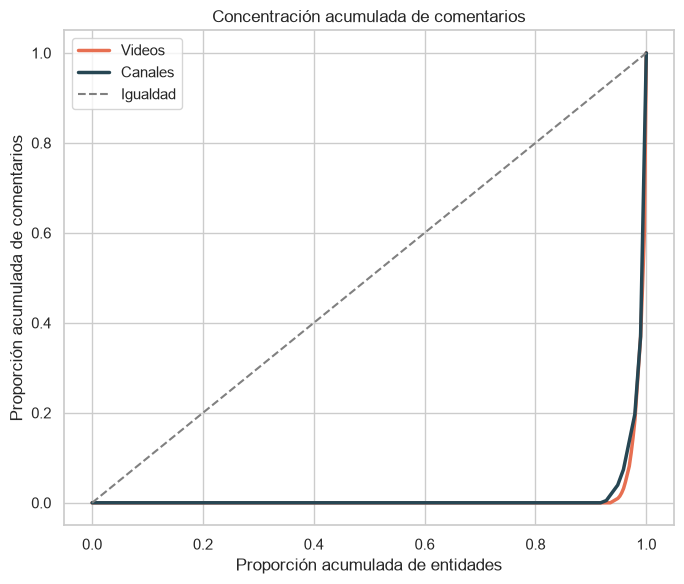

In [18]:
def concentration_row(entity, counts):
    counts = pd.Series(counts).sort_values(ascending=False)
    total = counts.sum()
    top_20_percent = max(1, int(np.ceil(0.20 * len(counts))))
    return {
        "entidad": entity, "cantidad_entidades": len(counts),
        "participación_top_1": counts.head(1).sum() / total,
        "participación_top_5": counts.head(5).sum() / total,
        "participación_top_10": counts.head(10).sum() / total,
        "participación_top_20pct_entidades": counts.head(top_20_percent).sum() / total,
    }

video_counts_all = videos[["video_id"]].merge(
    comments.groupby("video_id").size().rename("comentarios"),
    on="video_id", how="left",
)["comentarios"].fillna(0)
channel_counts_all = videos[["channel_id"]].drop_duplicates().merge(
    comments.groupby("channel_id").size().rename("comentarios"),
    on="channel_id", how="left",
)["comentarios"].fillna(0)

concentration = pd.DataFrame([
    concentration_row("videos", video_counts_all),
    concentration_row("canales", channel_counts_all),
])
percentage_columns = [column for column in concentration.columns if column.startswith("participación")]
display(concentration.style.format({column: "{:.1%}" for column in percentage_columns}))

def lorenz_points(values):
    values = np.sort(np.asarray(values, dtype=float))
    cumulative = np.insert(np.cumsum(values), 0, 0.0)
    cumulative = cumulative / cumulative[-1]
    population = np.linspace(0, 1, len(cumulative))
    return population, cumulative

fig, ax = plt.subplots(figsize=(7, 6))
for label, counts, color in [
    ("Videos", video_counts_all, COLORS["video"]),
    ("Canales", channel_counts_all, COLORS["accent"]),
]:
    x, y = lorenz_points(counts)
    ax.plot(x, y, label=label, linewidth=2.5, color=color)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Igualdad")
ax.set(title="Concentración acumulada de comentarios",
       xlabel="Proporción acumulada de entidades",
       ylabel="Proporción acumulada de comentarios")
ax.legend()
plt.tight_layout()
plt.show()

## 3.3 Popularidad y participación

Las visualizaciones miden exposición acumulada observada; los comentarios disponibles miden participación dentro de una recolección parcial. Se usa correlación de Spearman porque ambas variables son muy asimétricas y no se supone una relación lineal.

,rho_spearman,p_value,videos_comparables
0,0.0803,0.1703,293


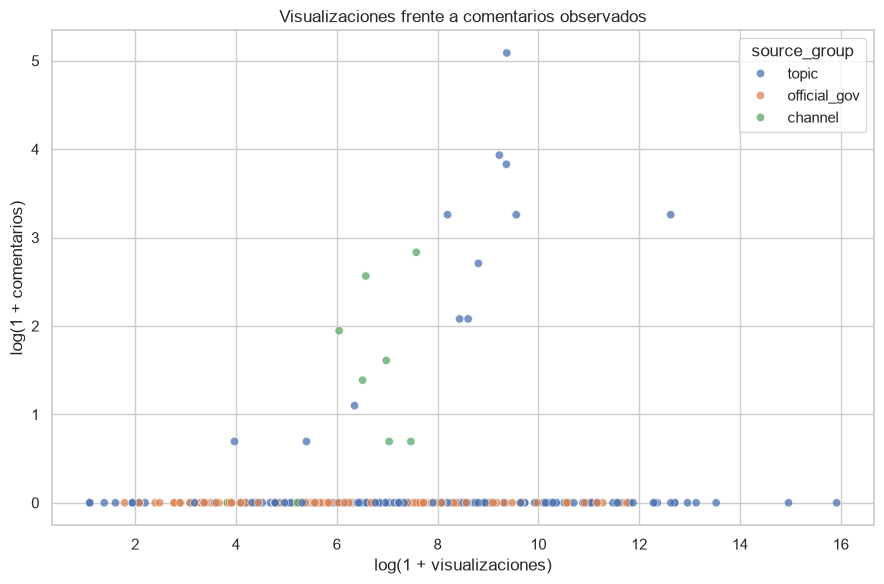

In [19]:
video_activity = videos[["video_id", "title", "channel_name", "source_group", "view_count"]].merge(
    comments.groupby("video_id").agg(
        comentarios=("comment_id", "size"), autores_unicos=("author_channel_id", "nunique"),
    ), on="video_id", how="left",
)
video_activity[["comentarios", "autores_unicos"]] = video_activity[["comentarios", "autores_unicos"]].fillna(0).astype(int)
correlation_data = video_activity.dropna(subset=["view_count"])
rho, p_value = spearmanr(correlation_data["view_count"], correlation_data["comentarios"])

display(pd.DataFrame([{
    "rho_spearman": rho, "p_value": p_value, "videos_comparables": len(correlation_data),
}]).round(4))

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=correlation_data,
    x=np.log1p(correlation_data["view_count"].astype(float)),
    y=np.log1p(correlation_data["comentarios"].astype(float)),
    hue="source_group", alpha=0.75, ax=ax,
)
ax.set(title="Visualizaciones frente a comentarios observados",
       xlabel="log(1 + visualizaciones)", ylabel="log(1 + comentarios)")
plt.tight_layout()
plt.show()

La correlación describe asociación, no causalidad. Además, los conteos no tienen la misma cobertura temporal: un video puede acumular vistas durante años mientras que el archivo contiene solo una selección de comentarios principales.

## 3.4 Visualizaciones pertinentes

Las visualizaciones anteriores comparan composición, distribuciones, frecuencias, concentración y asociación. Se conservaron escalas lineales para conteos pequeños y se usó log1p únicamente en variables de cola larga. Ninguna gráfica elimina observaciones; los ceros de comentarios permanecen visibles en la concentración y en la comparación con visualizaciones.

## 3.5 Respuestas a las preguntas obligatorias

Estas son respuestas preliminares basadas en los ejercicios 1–4. Comunidades y sentimiento se tratarán formalmente en los ejercicios 7 y 9; no se anticipan conclusiones que todavía no se han medido.

In [20]:
author_activity = (
    comments.groupby("author_channel_id")
    .agg(etiqueta=("author_handle", lambda s: s.dropna().iloc[0] if s.notna().any() else "sin handle"),
         comentarios=("comment_id", "size"), videos_unicos=("video_id", "nunique"),
         canales_unicos=("channel_id", "nunique"))
    .reset_index()
    .sort_values(["videos_unicos", "canales_unicos", "comentarios"], ascending=False)
)
shared_audience = author_activity["videos_unicos"].gt(1)
bridge_candidates = author_activity.head(3)["etiqueta"].astype(str).tolist()
top_video = comments_by_video.iloc[0]
top_channel = comments_by_channel.iloc[0]
theme_terms = ", ".join(top_words.head(5)["palabra"].astype(str))

mandatory_answers = pd.DataFrame([
    {"pregunta": "¿Qué videos y canales concentran mayor participación?",
     "respuesta_preliminar": f"El video con más comentarios observados es '{top_video['title']}' ({int(top_video['comentarios'])}); el canal con mayor conteo observado es '{top_channel['channel_name']}' ({int(top_channel['comentarios'])})."},
    {"pregunta": "¿Existen audiencias compartidas?",
     "respuesta_preliminar": f"Sí en la muestra: {int(shared_audience.sum())} de {len(author_activity)} autores ({shared_audience.mean():.1%}) comentaron más de un video. Esto es coparticipación, no amistad."},
    {"pregunta": "¿Qué autores funcionan como puentes?",
     "respuesta_preliminar": "Por diversidad de videos/canales, los primeros candidatos son " + ", ".join(bridge_candidates) + ". La intermediación formal se calculará en el ejercicio 8."},
    {"pregunta": "¿Qué temas y sentimientos caracterizan comunidades?",
     "respuesta_preliminar": f"En el corpus limpio destacan términos como {theme_terms}. Aún no se asignan temas a comunidades ni sentimientos: hacerlo antes de los ejercicios 7 y 9 sería especulativo."},
    {"pregunta": "¿Visibilidad y participación coinciden?",
     "respuesta_preliminar": f"La asociación de Spearman entre vistas y comentarios recolectados es rho={rho:.3f}. No implica equivalencia porque ambos conteos tienen coberturas distintas."},
    {"pregunta": "¿Qué limita las conclusiones?",
     "respuesta_preliminar": "La selección por consultas/canales, la cobertura parcial de comentarios, fechas relativas, conteos capturados en momentos distintos y la ausencia de relaciones explícitas entre autores."},
])
display(mandatory_answers)

,pregunta,respuesta_preliminar
0,¿Qué videos y canales concentran mayor participación?,El video con más comentarios observados es 'Qué rico come tu diputado' (161); el canal con mayor conteo observado es...
1,¿Existen audiencias compartidas?,"Sí en la muestra: 9 de 332 autores (2.7%) comentaron más de un video. Esto es coparticipación, no amistad."
2,¿Qué autores funcionan como puentes?,"Por diversidad de videos/canales, los primeros candidatos son /@hashojea7348, /@inge_vergueta, /@virgiliogarcia3039...."
3,¿Qué temas y sentimientos caracterizan comunidades?,"En el corpus limpio destacan términos como no, pueblo, guatemala, dinero, presidente. Aún no se asignan temas a comu..."
4,¿Visibilidad y participación coinciden?,La asociación de Spearman entre vistas y comentarios recolectados es rho=0.080. No implica equivalencia porque ambos...
5,¿Qué limita las conclusiones?,"La selección por consultas/canales, la cobertura parcial de comentarios, fechas relativas, conteos capturados en mom..."


## 3.6 Tres preguntas adicionales

Las respuestas se calculan directamente del corpus y ayudan a distinguir actividad recurrente, cobertura y recepción de respuestas.

In [21]:
videos_without_comments = int(video_activity["comentarios"].eq(0).sum())
authors_one_comment = int(author_activity["comentarios"].eq(1).sum())
comments_with_replies = int(comments["reply_count"].gt(0).sum())

additional_questions = pd.DataFrame([
    {"pregunta": "¿La mayoría de autores participa una sola vez?",
     "evidencia": f"{authors_one_comment} de {len(author_activity)} autores ({authors_one_comment / len(author_activity):.1%}) tienen exactamente un comentario observado."},
    {"pregunta": "¿Cuántos videos quedaron sin comentarios en el archivo?",
     "evidencia": f"{videos_without_comments} de {len(video_activity)} videos ({videos_without_comments / len(video_activity):.1%}) no tienen comentarios recolectados; esto no significa cero comentarios en YouTube."},
    {"pregunta": "¿Qué tan frecuente es recibir al menos una respuesta?",
     "evidencia": f"{comments_with_replies} de {len(comments)} comentarios ({comments_with_replies / len(comments):.1%}) tienen reply_count > 0; acumulan {int(comments['reply_count'].sum())} respuestas no identificadas."},
])
display(additional_questions)

,pregunta,evidencia
0,¿La mayoría de autores participa una sola vez?,286 de 332 autores (86.1%) tienen exactamente un comentario observado.
1,¿Cuántos videos quedaron sin comentarios en el archivo?,274 de 293 videos (93.5%) no tienen comentarios recolectados; esto no significa cero comentarios en YouTube.
2,¿Qué tan frecuente es recibir al menos una respuesta?,30 de 406 comentarios (7.4%) tienen reply_count > 0; acumulan 51 respuestas no identificadas.


# 4. Construcción de la red bipartita autor–video

## 4.1–4.3 Definición y tablas auditables

La red es no dirigida y tiene dos tipos de nodo:

- `author`: identificado por `author_channel_id`;
- `video`: identificado por `video_id`.

Existe una arista cuando un autor publicó al menos un comentario principal en un video. Su peso es el número de comentarios observados para ese par. Los prefijos `author::` y `video::` impiden colisiones accidentales entre espacios de IDs.

In [22]:
nodes, edges = build_network_tables(comments, videos)
graph = build_bipartite_graph(nodes, edges)
save_network_tables(nodes, edges)

isolates = list(nx.isolates(graph))
network_audit = pd.DataFrame([
    {"métrica": "nodos autores", "valor": int(nodes["node_type"].eq("author").sum())},
    {"métrica": "nodos videos", "valor": int(nodes["node_type"].eq("video").sum())},
    {"métrica": "nodos totales", "valor": graph.number_of_nodes()},
    {"métrica": "aristas autor-video", "valor": graph.number_of_edges()},
    {"métrica": "suma de pesos (comentarios utilizables)", "valor": int(edges["weight"].sum())},
    {"métrica": "videos aislados en la muestra", "valor": sum(node.startswith("video::") for node in isolates)},
    {"métrica": "autores aislados", "valor": sum(node.startswith("author::") for node in isolates)},
    {"métrica": "es bipartita", "valor": nx.algorithms.bipartite.is_bipartite(graph)},
])
display(network_audit)

,métrica,valor
0,nodos autores,332
1,nodos videos,293
2,nodos totales,625
3,aristas autor-video,343
4,suma de pesos (comentarios utilizables),406
5,videos aislados en la muestra,274
6,autores aislados,0
7,es bipartita,True


In [23]:
display(Markdown("**Muestra de la tabla de nodos**")); display(nodes.head(8))
display(Markdown("**Muestra de la tabla de aristas con mayor peso**")); display(edges.sort_values(["weight", "video_title"], ascending=[False, True]).head(12))

edge_validation = pd.DataFrame([
    {"validación": "IDs de nodos únicos", "cumple": nodes["node_id"].is_unique},
    {"validación": "pesos estrictamente positivos", "cumple": edges["weight"].gt(0).all()},
    {"validación": "todos los autores existen en nodos", "cumple": set(edges["source"]).issubset(set(nodes["node_id"]))},
    {"validación": "todos los videos existen en nodos", "cumple": set(edges["target"]).issubset(set(nodes["node_id"]))},
    {"validación": "suma de pesos = comentarios utilizables", "cumple": int(edges["weight"].sum()) == len(comments.dropna(subset=["author_channel_id", "video_id"]))},
])
display(edge_validation)

**Muestra de la tabla de nodos**

,node_id,node_type,original_id,label,author_name,author_handle,channel_id,channel_name,title,category,view_count,comment_count,unique_neighbors,unique_videos,unique_channels
0,author::UC-HeUTT6_g-VoiWds2a4H-w,author,UC-HeUTT6_g-VoiWds2a4H-w,/@JorgeMunoz-gd9et,@JorgeMunoz-gd9et,/@JorgeMunoz-gd9et,NaN,<NA>,<NA>,<NA>,<NA>,1,1,1,1
1,author::UC-Iul5tDYH_oiAMXQH-KaaQ,author,UC-Iul5tDYH_oiAMXQH-KaaQ,/@AlbertoMancilla-p9h,@AlbertoMancilla-p9h,/@AlbertoMancilla-p9h,NaN,<NA>,<NA>,<NA>,<NA>,1,1,1,1
2,author::UC-QOpE7GOxlXcHZ8b7HbQKA,author,UC-QOpE7GOxlXcHZ8b7HbQKA,/@mariaalexander427,@mariaalexander427,/@mariaalexander427,NaN,<NA>,<NA>,<NA>,<NA>,2,1,1,1
3,author::UC-fiZBS5Gp1eCJd9ucgWnCg,author,UC-fiZBS5Gp1eCJd9ucgWnCg,/@Tommii.10,@Tommii.10,/@Tommii.10,NaN,<NA>,<NA>,<NA>,<NA>,1,1,1,1
4,author::UC-hfX8J5JPJ-dfuakzegMLA,author,UC-hfX8J5JPJ-dfuakzegMLA,/@normaleticiaorozcojuarez2418,@normaleticiaorozcojuarez2418,/@normaleticiaorozcojuarez2418,NaN,<NA>,<NA>,<NA>,<NA>,1,1,1,1
5,author::UC-jS_kA9w-OmpupXDx156Rg,author,UC-jS_kA9w-OmpupXDx156Rg,/@simoncreyesc7579,@simoncreyesc7579,/@simoncreyesc7579,NaN,<NA>,<NA>,<NA>,<NA>,1,1,1,1
6,author::UC-pNP6RMFuLg_-x7Ah_0kEA,author,UC-pNP6RMFuLg_-x7Ah_0kEA,/@almacatalan2717,@almacatalan2717,/@almacatalan2717,NaN,<NA>,<NA>,<NA>,<NA>,1,1,1,1
7,author::UC094EFEmMSdwVa8NQjjYBXg,author,UC094EFEmMSdwVa8NQjjYBXg,/@CelestinoQuej-j7k,@CelestinoQuej-j7k,/@CelestinoQuej-j7k,NaN,<NA>,<NA>,<NA>,<NA>,1,1,1,1


**Muestra de la tabla de aristas con mayor peso**

,source,target,weight,author_channel_id,video_id,video_title,channel_id,channel_name
244,author::UCi2KiZq63sRq8Mfbcp-MelQ,video::OkXlHx0hx-8,6,UCi2KiZq63sRq8Mfbcp-MelQ,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo
331,author::UCyJhqmMbsvjpoarBBStA2kg,video::6W4u8sGEnGM,6,UCyJhqmMbsvjpoarBBStA2kg,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala
165,author::UCV3fr-YOixFKCZBbJP1-X4w,video::6W4u8sGEnGM,5,UCV3fr-YOixFKCZBbJP1-X4w,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala
33,author::UC5H8ASmMC9WrURmzeB4ySog,video::n8iP75gIpmw,5,UC5H8ASmMC9WrURmzeB4ySog,n8iP75gIpmw,Qué rico come tu diputado,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum
57,author::UC9vMq1YF-e7C-VO0SHkbUTA,video::n8iP75gIpmw,4,UC9vMq1YF-e7C-VO0SHkbUTA,n8iP75gIpmw,Qué rico come tu diputado,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum
120,author::UCNIeXbV_mEwpa412h1aqUWw,video::PjmxCj-a9Hg,3,UCNIeXbV_mEwpa412h1aqUWw,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala
226,author::UCg3eIfd7BrsLEqS0BLkftHA,video::PjmxCj-a9Hg,3,UCg3eIfd7BrsLEqS0BLkftHA,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala
25,author::UC3XTwHxygNCgjndsg-UiCQA,video::n8iP75gIpmw,3,UC3XTwHxygNCgjndsg-UiCQA,n8iP75gIpmw,Qué rico come tu diputado,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum
46,author::UC72gBAtyb_VXQlYDcFrh6oQ,video::n8iP75gIpmw,3,UC72gBAtyb_VXQlYDcFrh6oQ,n8iP75gIpmw,Qué rico come tu diputado,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum
85,author::UCFjudnPLoaSL1BaRuLahyHg,video::n8iP75gIpmw,3,UCFjudnPLoaSL1BaRuLahyHg,n8iP75gIpmw,Qué rico come tu diputado,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum


,validación,cumple
0,IDs de nodos únicos,True
1,pesos estrictamente positivos,True
2,todos los autores existen en nodos,True
3,todos los videos existen en nodos,True
4,suma de pesos = comentarios utilizables,True


## 4.4 Visualización de la red completa

Se dibujan todos los nodos y todas las aristas, incluidos los videos aislados. Solo se limitan las **etiquetas de texto** a los nodos con mayor grado para mantener legibilidad; no se filtra la estructura. El tamaño representa grado y el grosor de arista usa el peso.

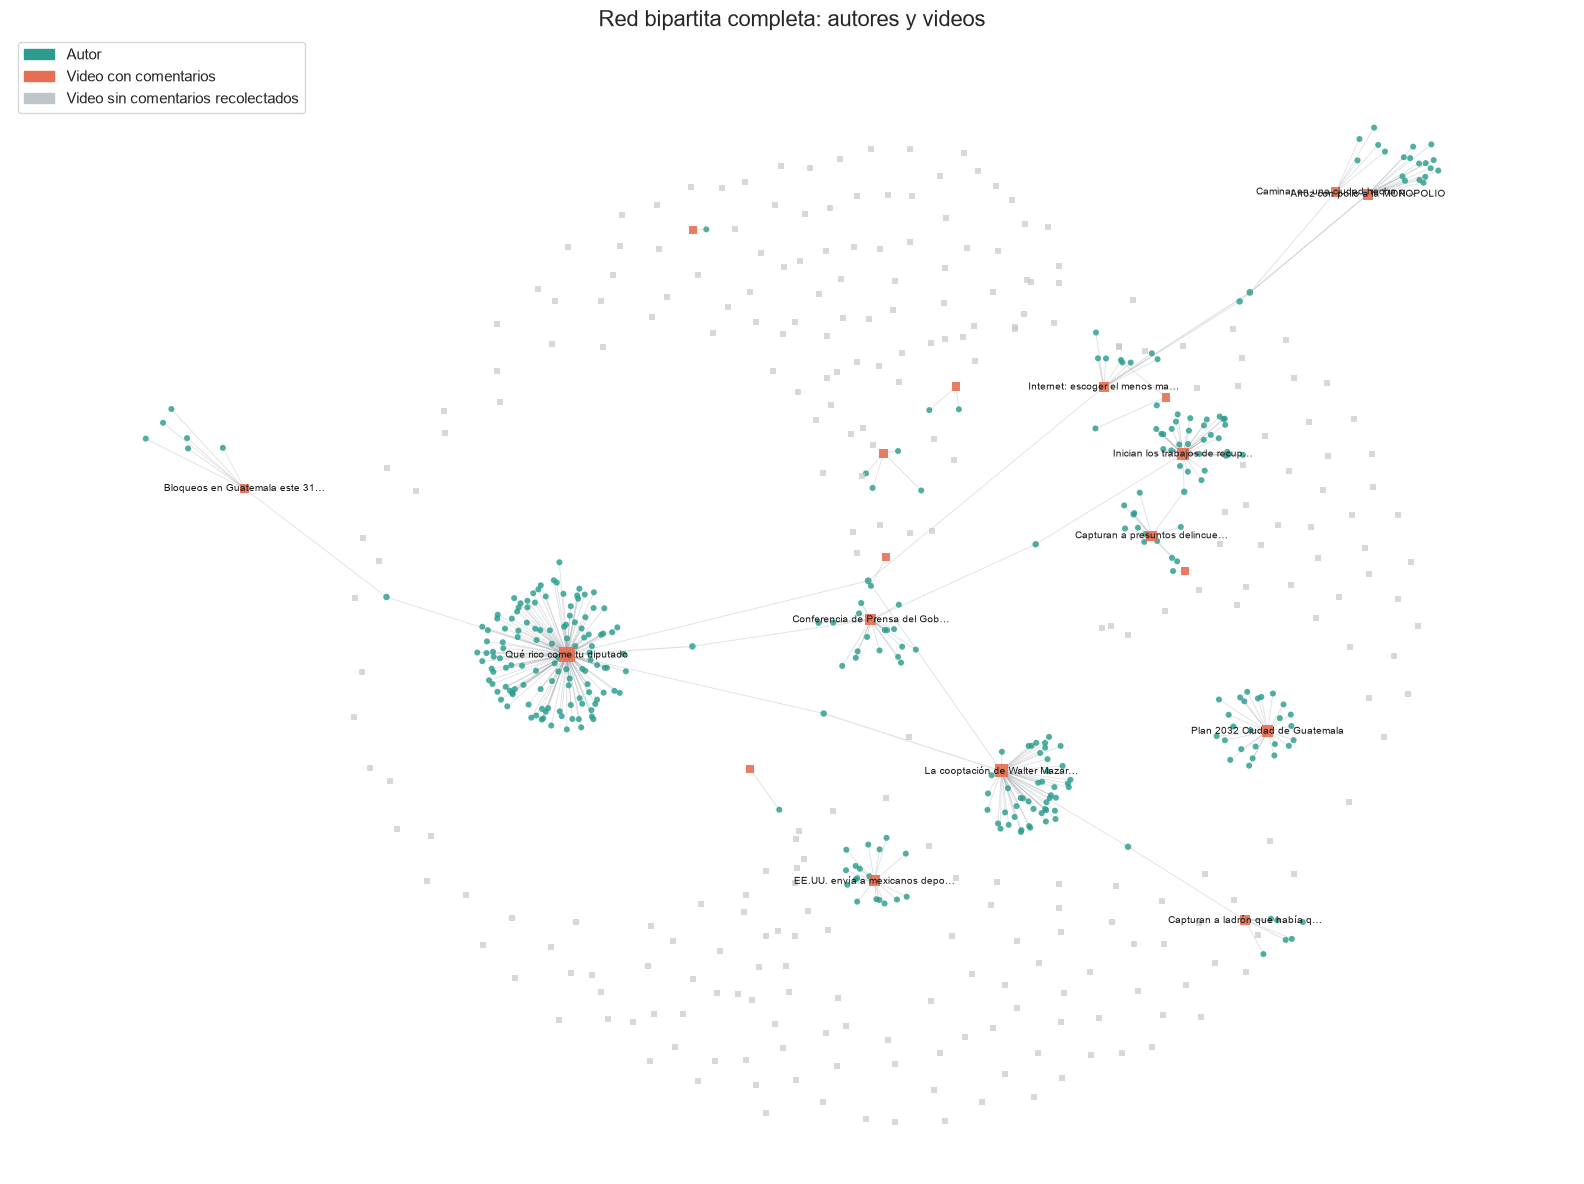

In [24]:
degrees = dict(graph.degree())
positions = nx.spring_layout(graph, seed=42, k=0.20, iterations=100, weight="weight")

author_nodes = [node for node, attrs in graph.nodes(data=True) if attrs["node_type"] == "author"]
video_nodes = [node for node, attrs in graph.nodes(data=True) if attrs["node_type"] == "video"]
isolated_videos = [node for node in video_nodes if degrees[node] == 0]
active_videos = [node for node in video_nodes if degrees[node] > 0]

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(
    graph, positions,
    width=[0.25 + 0.55 * np.log1p(graph[u][v]["weight"]) for u, v in graph.edges()],
    alpha=0.22, edge_color="#6C757D", ax=ax,
)
nx.draw_networkx_nodes(
    graph, positions, nodelist=author_nodes, node_color=COLORS["author"],
    node_size=[12 + 7 * np.sqrt(degrees[node]) for node in author_nodes],
    alpha=0.82, linewidths=0, ax=ax,
)
nx.draw_networkx_nodes(
    graph, positions, nodelist=active_videos, node_color=COLORS["video"], node_shape="s",
    node_size=[25 + 9 * np.sqrt(degrees[node]) for node in active_videos],
    alpha=0.9, linewidths=0, ax=ax,
)
nx.draw_networkx_nodes(
    graph, positions, nodelist=isolated_videos, node_color="#BFC5C9", node_shape="s",
    node_size=18, alpha=0.65, linewidths=0, ax=ax,
)

top_label_nodes = sorted(
    (node for node in graph.nodes if degrees[node] > 0),
    key=lambda node: degrees[node], reverse=True,
)[:12]
labels = {
    node: shorten(graph.nodes[node].get("label", graph.nodes[node].get("original_id", node)), 30)
    for node in top_label_nodes
}
nx.draw_networkx_labels(graph, positions, labels=labels, font_size=7, ax=ax)

ax.legend(handles=[
    Patch(color=COLORS["author"], label="Autor"),
    Patch(color=COLORS["video"], label="Video con comentarios"),
    Patch(color="#BFC5C9", label="Video sin comentarios recolectados"),
], loc="upper left")
ax.set_title("Red bipartita completa: autores y videos", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

## 4.5 Interpretación correcta de una arista

Una arista representa únicamente que un autor publicó uno o más comentarios principales en un video dentro de los datos recolectados. El peso cuenta esos comentarios. La relación **no** demuestra amistad, conversación directa, respuesta entre usuarios, aprobación, identidad fuera de YouTube ni exposición completa al video. Dos autores todavía no están conectados entre sí en esta red; esa relación aparecerá solo como coparticipación en la proyección autor–autor del ejercicio 5.

# Cierre del avance

El flujo deja listas las tablas limpias, la integración comentario–video y las tablas de nodos y aristas. Se preservan las observaciones extremas y los videos sin comentarios porque ambos elementos son parte de la estructura observada. Las respuestas sobre comunidades, centralidad formal y sentimiento quedan delimitadas para los ejercicios 5–10 y no se presentan como hallazgos antes de calcularlas.

Las conclusiones de este avance describen **esta muestra recolectada**. No se generalizan a todos los usuarios de YouTube ni a toda la población de Guatemala.